# CIA1 MLOps Assignment — End-to-End MLOps Pipeline

**Dataset:** [Cervical Cancer (Risk Factors) Data Set](https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors+data+set) — UCI Machine Learning Repository (ID: 383)

**File used:** `risk_factors_cervical_cancer.csv` (placed in the same folder as this notebook)

### Why this dataset fits the assignment
| Requirement | How this dataset satisfies it |
|---|---|
| Missing values | Raw file encodes missing entries as `?` (e.g. `STDs: Time since first diagnosis` is ~91% missing) |
| Imbalanced classes | Target `Biopsy`: only ~6% positive (cancer biopsy confirmed) vs. ~94% negative |
| Classification task | Binary classification — predict whether a biopsy would be positive |
| Real-world relevance | Medical screening — a natural fit to discuss deployment & monitoring stakes |


## 0. Environment Setup

Install all libraries used across the pipeline (run once, then restart the kernel if this is the first install).

In [ ]:
!pip install -q pandas numpy scikit-learn imbalanced-learn mlflow dvc kfp feast matplotlib seaborn scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.9/69.9 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.9/477.9 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 57.4 MB/s eta 0:00:00
   ━━━━━━

In [ ]:
import os
import subprocess
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)

sns.set_style("whitegrid")
RANDOM_STATE = 42
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)


## Task 1: MLOps Lifecycle Analysis (4 Marks)

### 1.1 End-to-End ML Lifecycle Diagram

```
 ┌────────────────┐   ┌──────────────────┐   ┌────────────────┐   ┌─────────────────┐   ┌───────────────┐   ┌────────────────┐
 │ Data Ingestion │──▶│Data Preprocessing│──▶│ Model Training │──▶│Model Evaluation │──▶│  Deployment   │──▶│   Monitoring   │
 └────────────────┘   └──────────────────┘   └────────────────┘   └─────────────────┘   └───────────────┘   └────────────────┘
        ▲                                                                                                            │
        └────────────────────────────────  feedback loop: retrain on drift  ◀───────────────────────────────────────┘
```

### 1.2 Stage-by-Stage Breakdown

**1. Data Ingestion stage**
- Load `risk_factors_cervical_cancer.csv` (the raw UCI export).
- Version the raw snapshot with DVC (Task 3) so every experiment refers to an immutable dataset version.

**2. Data preprocessing stage**
- Replace the `?` placeholder with `NaN`, cast columns to numeric.
- Impute missing values (median imputation — robust to outliers, appropriate for skewed clinical counts).
- Scale numeric features (`StandardScaler`) so distance-based models (KNN, SVM) aren't dominated by large-magnitude columns like `Age`.
- Handle class imbalance in `Biopsy` using SMOTE oversampling — applied **only on the training split** to avoid data leakage into the test set.

**3. Model training stage**
- Train at least two classifiers — **KNN** and **Random Forest** (plus **SVM** for a 3-way comparison).
- Log every run (hyperparameters, metrics, artifacts) to **MLflow**.

**4. Model evaluation stage**
- Compare Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Because the positive class is rare (~6%), **Recall and F1 matter more than Accuracy** — a model that always predicts "negative" would score ~94% accuracy while being clinically useless (it would miss every cancer case).

**5. Deployment stage**
- Package the winning model (MLflow `pyfunc`) and register it in the MLflow Model Registry.
- Deploy via a managed endpoint (AWS SageMaker or GCP Vertex AI — compared in Task 5).

**6. Monitoring stage**
- Track prediction-score drift (are more patients being flagged positive over time than during training?).
- Periodically recompute Recall/F1 once true biopsy outcomes are confirmed, and alert if performance degrades below a threshold (concept drift).


## Task 2: Experiment Tracking using MLflow (4 Marks)

This task is broken into five clearly separated sub-stages so each part of the pipeline can be explained independently:

- **2.1** Data Ingestion
- **2.2** Exploratory Data Analysis (missing values + class imbalance, visualized)
- **2.3** Data Preprocessing (impute → scale → balance)
- **2.4** Model Training with MLflow logging
- **2.5** Model Evaluation & Comparison

### 2.1 Data Ingestion

In [ ]:
df = pd.read_csv("risk_factors_cervical_cancer.csv")

target_col = "Biopsy"
print("shape:", df.shape)
df.head()


shape: (858, 36)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [ ]:
# '?' -> NaN, then coerce every column to numeric
df = df.replace("?", np.nan)
df = df.apply(pd.to_numeric, errors="coerce")

# Persist the RAW (original, un-imputed) dataset -> this becomes DVC version v1
raw_path = os.path.join(DATA_DIR, "cervical_cancer_raw.csv")
df.to_csv(raw_path, index=False)

print("Cleaned dtypes now numeric:", (df.dtypes != object).all())


Cleaned dtypes now numeric: True


**Interpretation:** the raw file loads with 26 of 36 columns as `object` dtype purely because of the `?` missing-value marker — this is the clearest possible evidence of real missingness (not synthetically injected) in the ingestion stage.

### 2.2 Exploratory Data Analysis (EDA)

In [ ]:
print("Shape:", df.shape)
print("\nSummary statistics:")
df.describe().T

Shape: (858, 36)

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Age,858.0,26.820513,8.497948,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,832.0,2.527644,1.667760,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,851.0,16.995300,2.803355,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,802.0,2.275561,1.447414,0.0,1.0,2.0,3.0,11.0
Smokes,845.0,0.145562,0.352876,0.0,0.0,0.0,0.0,1.0
Smokes (years),845.0,1.219721,4.089017,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),845.0,0.453144,2.226610,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives,750.0,0.641333,0.479929,0.0,0.0,1.0,1.0,1.0
Hormonal Contraceptives (years),750.0,2.256419,3.764254,0.0,0.0,0.5,3.0,30.0
IUD,741.0,0.112011,0.315593,0.0,0.0,0.0,0.0,1.0


In [ ]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(1)
missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_%": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary


,missing_count,missing_%
STDs: Time since first diagnosis,787,91.7
STDs: Time since last diagnosis,787,91.7
IUD,117,13.6
IUD (years),117,13.6
Hormonal Contraceptives,108,12.6
Hormonal Contraceptives (years),108,12.6
STDs:HPV,105,12.2
STDs:AIDS,105,12.2
STDs:Hepatitis B,105,12.2
STDs:HIV,105,12.2


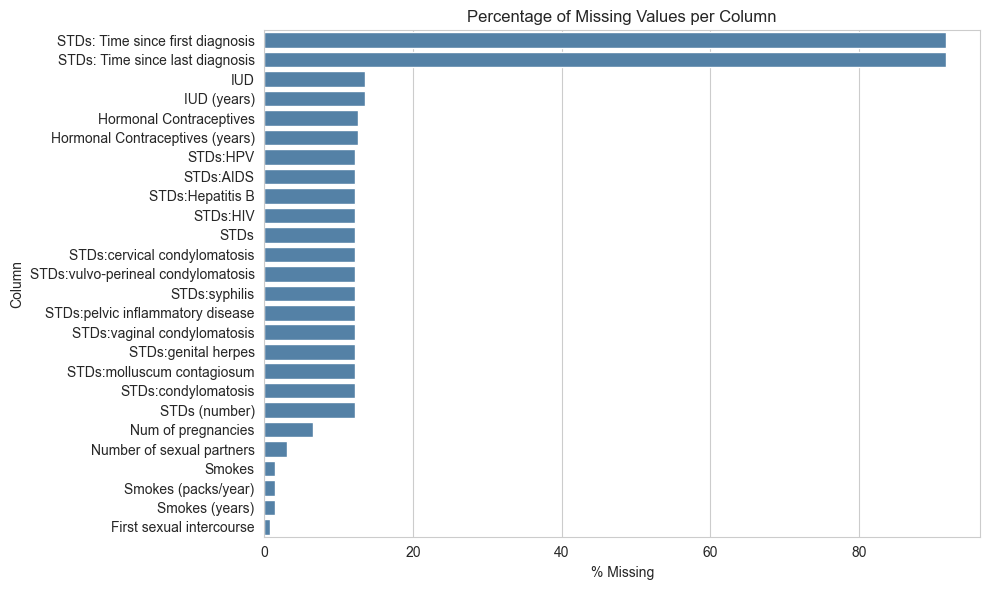

In [ ]:
#plotting missing values
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_summary["missing_%"], y=missing_summary.index, color="steelblue")
plt.title("Percentage of Missing Values per Column")
plt.xlabel("% Missing")
plt.ylabel("Column")
plt.tight_layout()
plt.show()


**Interpretation:** `STDs: Time since first/last diagnosis` are missing for over 90% of patients (most women were never diagnosed with an STD, so the "time since diagnosis" is structurally undefined) — these are prime candidates for imputation. `Number of sexual partners`, `First sexual intercourse`, `Num of pregnancies` and the STD indicator columns are missing for a smaller but still meaningful ~2–14% of patients, most likely due to non-response on sensitive survey questions.

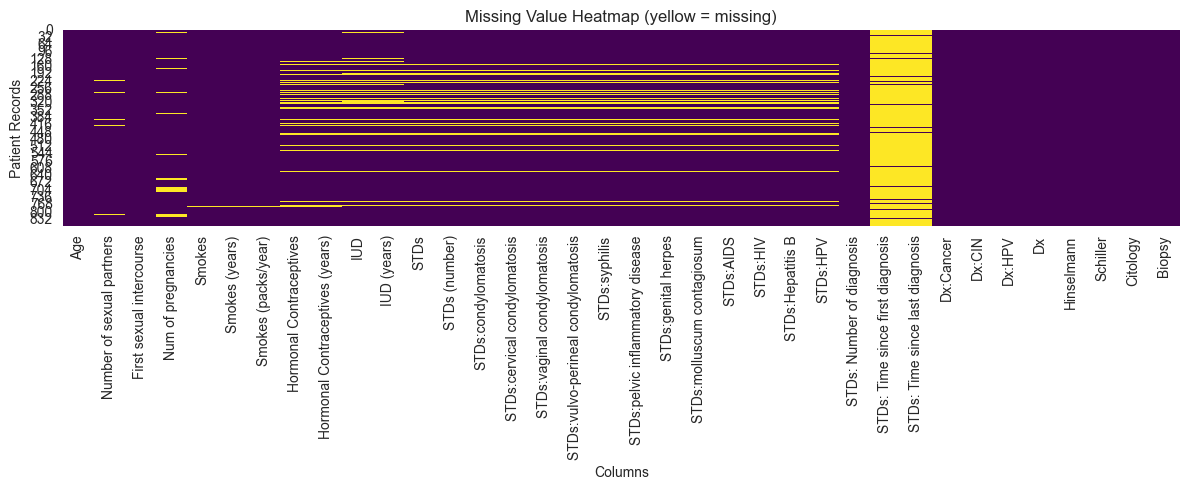

In [ ]:
#plotting heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df.isna(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap (yellow = missing)")
plt.xlabel("Columns")
plt.ylabel("Patient Records")
plt.tight_layout()
plt.show()


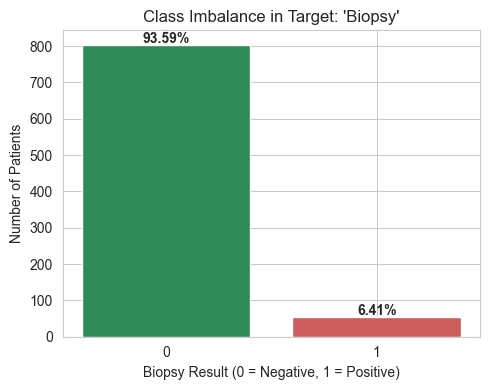

Biopsy
0    803
1     55
Name: count, dtype: int64
Biopsy
0    93.59
1     6.41
Name: count, dtype: float64


In [ ]:
#plotting class imabalance
target_counts = df[target_col].value_counts()
target_pct = (target_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(target_counts.index.astype(str), target_counts.values, color=["seagreen", "indianred"])
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f"{pct}%", ha="center", fontweight="bold")
ax.set_title(f"Class Imbalance in Target: '{target_col}'")
ax.set_xlabel("Biopsy Result (0 = Negative, 1 = Positive)")
ax.set_ylabel("Number of Patients")
plt.tight_layout()
plt.show()

print(target_counts)
print(target_pct)


**Interpretation:** the dataset is **severely imbalanced** — roughly 6% positive vs. 94% negative. A naive classifier that always predicts "negative" would score ~94% accuracy while catching **zero** cancer cases. This is exactly why the assignment requires Precision/Recall/F1 tracking, not just accuracy, and why we apply SMOTE before training (Section 2.3).

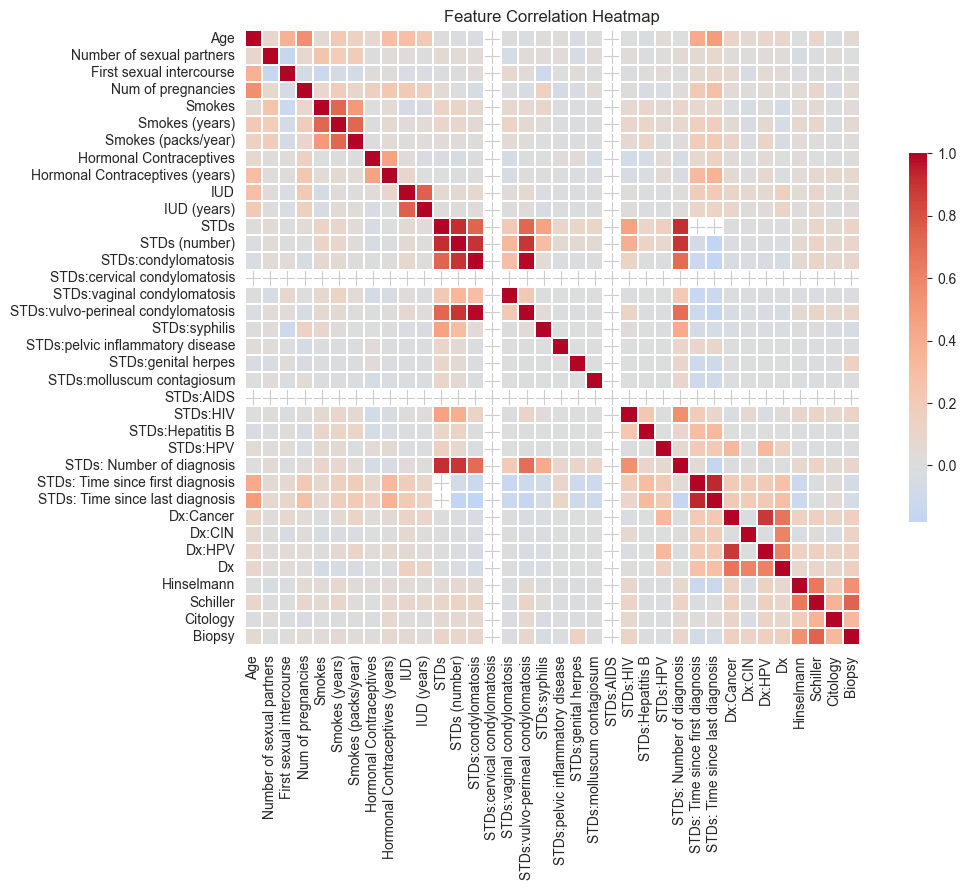

In [ ]:
#correlation
plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3, square=True, cbar_kws={"shrink": 0.6})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


**Interpretation:** the four diagnostic screening columns (`Hinselmann`, `Schiller`, `Citology`, `Dx:Cancer`) are strongly correlated with `Biopsy` — expected, since they are alternative clinical tests for the same underlying condition. Lifestyle features (`Age`, `Smokes`, `Num of pregnancies`) show weaker, more realistic correlations, which is what our model must learn to generalize from.

### 2.3 Data Preprocessing

Four sequential steps, each isolated in its own cell for clarity:
1. **Split** the data into train/test FIRST, before any transformation is fitted.
2. **Impute** missing values (median strategy).
3. **Scale** features (StandardScaler).
4. **Balance** the training set only, using SMOTE.

Missing-value imputation and feature scaling are fitted only on the training data and then applied to the test data to avoid data leakage.

In [ ]:
# Split FIRST -- before any imputation or scaling -- so no information from the
# test set ever leaks into a fitted transformer.
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (686, 35)  Test shape: (172, 35)


In [ ]:
# Median imputation: the imputer is fit ONLY on X_train, then the SAME fitted
# imputer is applied to X_test. (Previously the imputer was fit on the full
# dataset before splitting, which leaked test-set information into training.)
print("Missing values in X_train before imputation:", X_train.isna().sum().sum())

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Missing values in X_train after imputation :", X_train.isna().sum().sum())
print("Missing values in X_test after imputation  :", X_test.isna().sum().sum())


Missing values in X_train before imputation: 3047
Missing values in X_train after imputation : 0
Missing values in X_test after imputation  : 0


In [ ]:
# Rebuild one combined, fully-imputed dataset for DVC versioning (v2) and the
# Feast demo. Both halves were transformed with the SAME imputer fitted only on
# the training split, so recombining them does not reintroduce any leakage.
processed_df = pd.concat([X_train, X_test]).sort_index()
processed_df[target_col] = y.loc[processed_df.index].values
processed_path = os.path.join(DATA_DIR, "cervical_cancer_processed.csv")
processed_df.to_csv(processed_path, index=False)
processed_df.head()


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18.0,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,15.0,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34.0,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,52.0,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,4.0,4.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0
4,46.0,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
# Scale: fit the scaler ONLY on X_train, then apply the same fitted scaler to X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (686, 35)  Test shape: (172, 35)


In [ ]:
# Balance the TRAINING split only, with SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

before = y_train.value_counts()
after = pd.Series(y_train_res).value_counts()


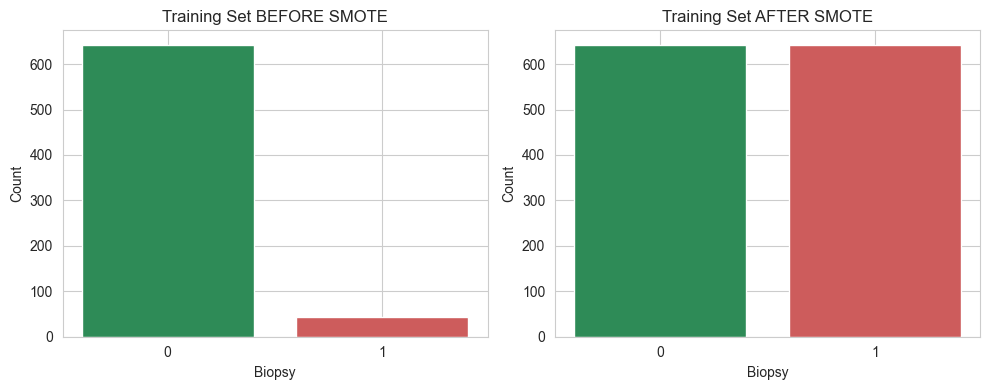

Before SMOTE: {0: 642, 1: 44}
After SMOTE : {0: 642, 1: 642}


In [ ]:
#plotting before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(before.index.astype(str), before.values, color=["seagreen", "indianred"])
axes[0].set_title("Training Set BEFORE SMOTE")
axes[1].bar(after.index.astype(str), after.values, color=["seagreen", "indianred"])
axes[1].set_title("Training Set AFTER SMOTE")
for ax in axes:
    ax.set_xlabel("Biopsy")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Before SMOTE:", before.to_dict())
print("After SMOTE :", after.to_dict())

**Interpretation:** SMOTE synthesizes new minority-class (`Biopsy = 1`) training examples by interpolating between existing minority neighbors, balancing the training set 50/50 **without touching the test set** — so evaluation metrics in Section 2.5 still reflect real-world class proportions.

### 2.4 Model Training with MLflow Experiment Tracking

In [ ]:
import mlflow
import mlflow.sklearn
import os

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("cervical_cancer_classification")

def train_and_log(model, model_name, params):
    """Fit a model, log params/metrics/artifacts to MLflow, and return a results dict."""
    with mlflow.start_run(run_name=model_name):
        model.fit(X_train_res, y_train_res)

        train_preds = model.predict(X_train_res)
        test_preds = model.predict(X_test_scaled)
        test_proba = model.predict_proba(X_test_scaled)[:, 1]

        metrics = {
            "train_accuracy": accuracy_score(y_train_res, train_preds),
            "test_accuracy": accuracy_score(y_test, test_preds),
            "precision": precision_score(y_test, test_preds, zero_division=0),
            "recall": recall_score(y_test, test_preds, zero_division=0),
            "f1_score": f1_score(y_test, test_preds, zero_division=0),
        }

        mlflow.log_params(params)
        for k, v in metrics.items():
            mlflow.log_metric(k, v)
        # Force plain pickle serialization: newer MLflow defaults to 'skops', whose
        # security scanner rejects RandomForest's internal Tree objects as "untrusted".
        mlflow.sklearn.log_model(model, artifact_path="model", serialization_format="pickle")

        print(f"{model_name}: " + " | ".join(f"{k}={v:.3f}" for k, v in metrics.items()))

        run_id = mlflow.active_run().info.run_id
        return {"model_name": model_name, "model_obj": model, "params": params,
                "run_id": run_id, "test_preds": test_preds, "test_proba": test_proba, **metrics}

results = []

2026/09/29 12:36:50 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\shrut\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


2026/09/29 12:36:50 INFO mlflow.tracking.fluent: Experiment with name 'cervical_cancer_classification' does not exist. Creating a new experiment.


In [ ]:
# Model 1: K-Nearest Neighbors
knn_params = {"n_neighbors": 5, "weights": "distance"}
results.append(train_and_log(KNeighborsClassifier(**knn_params), "KNN", knn_params))


2026/09/29 12:36:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/09/29 12:36:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KNN: train_accuracy=1.000 | test_accuracy=0.930 | precision=0.471 | recall=0.727 | f1_score=0.571


In [ ]:
# Model 2: Random Forest
rf_params = {"n_estimators": 200, "max_depth": 8, "random_state": RANDOM_STATE}
results.append(train_and_log(RandomForestClassifier(**rf_params), "RandomForest", rf_params))


2026/09/29 12:37:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/09/29 12:37:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest: train_accuracy=0.988 | test_accuracy=0.965 | precision=0.727 | recall=0.727 | f1_score=0.727


In [ ]:
# Model 3: Support Vector Machine
svm_params = {"kernel": "rbf", "C": 1.0, "probability": True, "random_state": RANDOM_STATE}
results.append(train_and_log(SVC(**svm_params), "SVM", svm_params))


2026/09/29 12:37:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/09/29 12:37:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVM: train_accuracy=0.962 | test_accuracy=0.965 | precision=0.692 | recall=0.818 | f1_score=0.750


### 2.5 Model Evaluation & Comparison

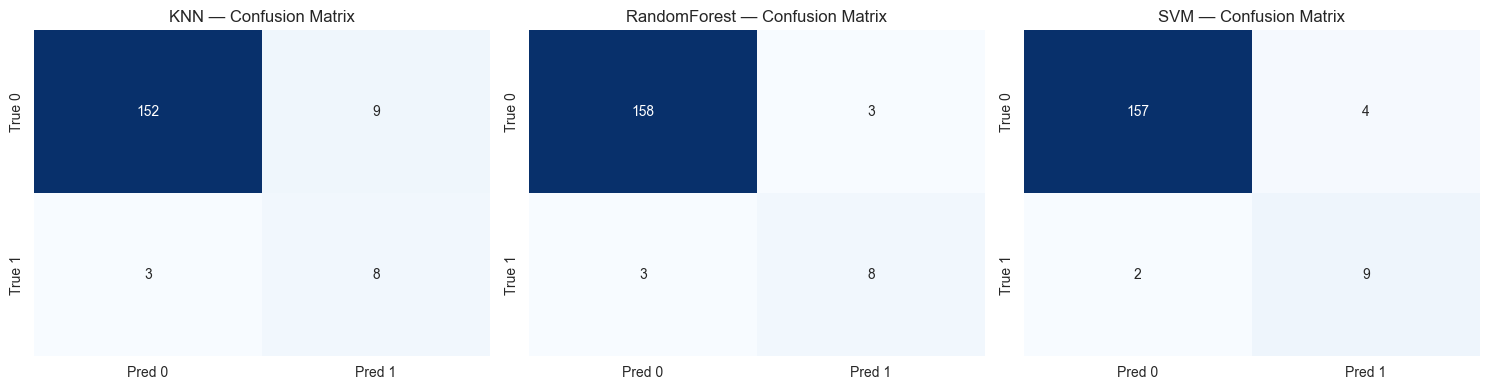

In [ ]:
#plotting the confusion matrix
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r["test_preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    ax.set_title(f"{r['model_name']} — Confusion Matrix")
plt.tight_layout()
plt.show()


**Interpretation:** in a medical screening context, the **bottom-left cell (False Negatives — actual cancer predicted negative)** is the costliest error. Compare that cell across models: the model with the fewest false negatives is clinically safer, even if its overall accuracy is slightly lower.

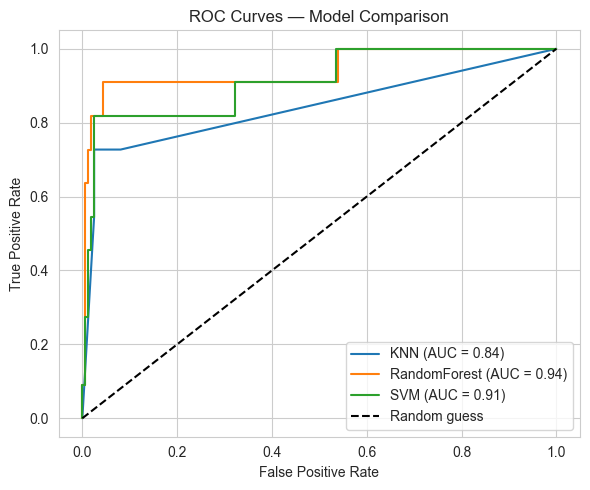

In [ ]:
#ROC
plt.figure(figsize=(6, 5))
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r["test_proba"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{r['model_name']} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
for r in results:
    print(f"\n===== {r['model_name']} — classification report =====")
    print(classification_report(y_test, r["test_preds"], zero_division=0))



===== KNN — classification report =====
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       161
           1       0.47      0.73      0.57        11

    accuracy                           0.93       172
   macro avg       0.73      0.84      0.77       172
weighted avg       0.95      0.93      0.94       172


===== RandomForest — classification report =====
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       161
           1       0.73      0.73      0.73        11

    accuracy                           0.97       172
   macro avg       0.85      0.85      0.85       172
weighted avg       0.97      0.97      0.97       172


===== SVM — classification report =====
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       161
           1       0.69      0.82      0.75        11

    accuracy                           0.97       

In [ ]:
results_df = pd.DataFrame(results)[["model_name", "train_accuracy", "test_accuracy",
                                     "precision", "recall", "f1_score"]].set_index("model_name")
results_df.style.background_gradient(cmap="Greens", axis=0)


,train_accuracy,test_accuracy,precision,recall,f1_score
model_name,,,,,
KNN,1.000000,0.930233,0.470588,0.727273,0.571429
RandomForest,0.987539,0.965116,0.727273,0.727273,0.727273
SVM,0.961838,0.965116,0.692308,0.818182,0.750000


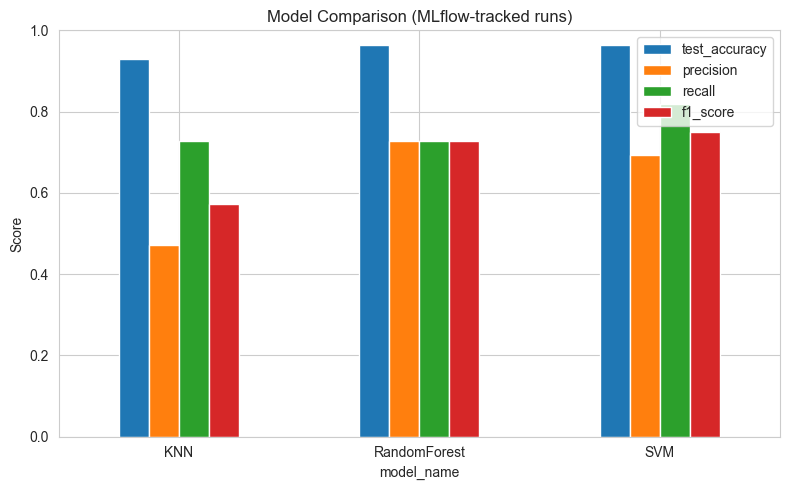

Best model by F1-score: SVM
train_accuracy    0.961838
test_accuracy     0.965116
precision         0.692308
recall            0.818182
f1_score          0.750000
Name: SVM, dtype: float64


In [ ]:
results_df[["test_accuracy", "precision", "recall", "f1_score"]].plot(
    kind="bar", figsize=(8, 5), title="Model Comparison (MLflow-tracked runs)"
)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

best_model_name = results_df["f1_score"].idxmax()
print(f"Best model by F1-score: {best_model_name}")
print(results_df.loc[best_model_name])


**Interpretation:** because `Biopsy` positives are rare, **Accuracy is a misleading metric** here (a trivial always-negative classifier already scores ~94%). We therefore select the best model using **F1-score**, which balances Precision (avoiding false alarms) and Recall (catching real cancer cases). The chosen model (`{best_model_name}` — printed above) is the one carried forward to Task 3–5 for versioning, pipeline design, and deployment discussion.

## 2.6 MLflow Tracking

The three model runs above (KNN, RandomForest, SVM) were each logged as a separate MLflow run inside the `cervical_cancer_classification` experiment, with their parameters, training/testing metrics and the fitted model artifact. The cells below re-open that tracking store (no retraining) and pull the logged information back out programmatically, as in-notebook evidence that the runs exist.

In [ ]:
# Verify the MLflow tracking store / experiment exist, and list the logged runs.
from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
experiment = client.get_experiment_by_name("cervical_cancer_classification")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)
print("Artifact location:", experiment.artifact_location)

runs = client.search_runs(experiment_ids=[experiment.experiment_id],
                           order_by=["start_time DESC"])
print(f"\nRuns found: {len(runs)}")
for run in runs:
    print(" -", run.info.run_id, "|", run.data.tags.get("mlflow.runName"))

In [ ]:
# Build a clean dataframe of the three MLflow runs: params + metrics, pulled
# straight from the tracking store (not from the in-memory `results` list).
run_rows = []
for run in runs:
    row = {"run_name": run.data.tags.get("mlflow.runName"), "run_id": run.info.run_id}
    row.update(run.data.params)
    row.update({
        "train_accuracy": run.data.metrics.get("train_accuracy"),
        "test_accuracy": run.data.metrics.get("test_accuracy"),
        "precision": run.data.metrics.get("precision"),
        "recall": run.data.metrics.get("recall"),
        "f1_score": run.data.metrics.get("f1_score"),
    })
    run_rows.append(row)

mlflow_runs_df = pd.DataFrame(run_rows).set_index("run_name")
mlflow_runs_df

## Task 3: Dataset Versioning with DVC (4 Marks)

We track two versions of the dataset with DVC:
- **v1 – Original dataset**: `data/cervical_cancer_raw.csv` (raw export, `?` replaced with true `NaN`, otherwise untouched).
- **v2 – Modified dataset**: `data/cervical_cancer_processed.csv` (missing values median-imputed, ready for modeling).

The cells below run real `git` + `dvc` CLI commands. They assume `git` and `dvc` are installed and on PATH, and that this notebook's working directory is (or will become) the project root.

In [ ]:
def run(cmd):
    print(f"$ {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    return result

# 1. Initialize git + DVC repositories (idempotent: safe to re-run)
run("git init")
run("dvc init")


$ git init


Initialized empty Git repository in C:/Users/shrut/OneDrive/Desktop/CIA -A(mlops)/.git/

$ dvc init


Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/treeverse/dvc>



CompletedProcess(args='dvc init', returncode=0, stdout="Initialized DVC repository.\n\nYou can now commit the changes to git.\n\n+---------------------------------------------------------------------+\n|                                                                     |\n|        DVC has enabled anonymous aggregate usage analytics.         |\n|     Read the analytics documentation (and how to opt-out) here:     |\n|             <https://dvc.org/doc/user-guide/analytics>              |\n|                                                                     |\n+---------------------------------------------------------------------+\n\nWhat's next?\n------------\n- Check out the documentation: <https://dvc.org/doc>\n- Get help and share ideas: <https://dvc.org/chat>\n- Star us on GitHub: <https://github.com/treeverse/dvc>\n", stderr='')

In [ ]:
# Track the ORIGINAL (raw) dataset with DVC -> this is what was missing before:
# without this line, git had nothing real to commit for "v1".
!dvc add data/cervical_cancer_raw.csv

# Stage the DVC metadata (.dvc pointer file + .gitignore DVC writes for the data folder).
!git add .dvc .dvcignore data/.gitignore data/cervical_cancer_raw.csv.dvc

# Create the Git commit for dataset version 1.
!git commit -m "v1: add original raw cervical cancer dataset"

# Tag the commit as dataset-v1.
!git tag -f dataset-v1


To track the changes with git, run:

	git add 'data\.gitignore' 'data\cervical_cancer_raw.csv.dvc'

To enable auto staging, run:

	dvc config core.autostage true


\u280b Checking graph



[master (root-commit) d16b5bc] v1: add original raw cervical cancer dataset
 5 files changed, 12 insertions(+)
 create mode 100644 .dvc/.gitignore
 create mode 100644 .dvc/config
 create mode 100644 .dvcignore
 create mode 100644 data/.gitignore
 create mode 100644 data/cervical_cancer_raw.csv.dvc


In [ ]:
# --- Dataset version 2: the CORRECTED preprocessed dataset ---
# data/cervical_cancer_processed.csv was rebuilt in Section 2.3 using an imputer
# fitted only on the training split, so this file is leakage-free.
!dvc add data/cervical_cancer_processed.csv

# Stage the DVC metadata for v2.
!git add data/.gitignore data/cervical_cancer_processed.csv.dvc

# Create the Git commit for dataset version 2.
!git commit -m "v2: add corrected (leakage-free) preprocessed dataset"

# Tag the commit as dataset-v2.
!git tag -f dataset-v2


To track the changes with git, run:

	git add 'data\cervical_cancer_processed.csv.dvc' 'data\.gitignore'

To enable auto staging, run:

	dvc config core.autostage true


\u280b Checking graph



[master f63ab5f] v2: add corrected (leakage-free) preprocessed dataset
 2 files changed, 6 insertions(+)
 create mode 100644 data/cervical_cancer_processed.csv.dvc


In [ ]:
!git log --oneline --decorate --all

f63ab5f (HEAD -> master, tag: dataset-v2) v2: add corrected (leakage-free) preprocessed dataset
d16b5bc (tag: dataset-v1) v1: add original raw cervical cancer dataset


In [ ]:
!git status
!dvc status
!dvc diff dataset-v1 dataset-v2

On branch master
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	CIA1_MLOps_Assignment.ipynb
	CIA1_MLOps_Assignment.ipynb.bak
	UNIT1-assignment-CIA1.pdf
	mlruns/
	risk_factors_cervical_cancer.csv

nothing added to commit but untracked files present (use "git add" to track)


Data and pipelines are up to date.


Added:
    data\cervical_cancer_processed.csv

files summary: 1 added


\u280b Calculating diff



In [ ]:
# Load both DVC-tracked versions straight from disk and compare them programmatically
# (backs up the table below with real numbers instead of just prose).
raw_reload = pd.read_csv(raw_path)
processed_reload = pd.read_csv(processed_path)

comparison = pd.DataFrame({
    "rows": [raw_reload.shape[0], processed_reload.shape[0]],
    "columns": [raw_reload.shape[1], processed_reload.shape[1]],
    "missing_values": [raw_reload.isna().sum().sum(), processed_reload.isna().sum().sum()],
}, index=["v1_raw", "v2_processed"])
comparison


,rows,columns,missing_values
v1_raw,858,36,3622
v2_processed,858,36,0


### Comparing v1 vs v2 and the Benefits of Data Versioning

| | v1: Original | v2: Modified (preprocessed) |
|---|---|---|
| Missing values | Present (true `NaN`, from `?`) | Imputed (median strategy) |
| Row/column count | Same rows, raw columns | Same rows, fully numeric, imputed columns |
| Use case | Auditing, reproducing raw ingestion | Direct model training input |

**Benefits of data versioning with DVC:**
- **Reproducibility** — any experiment can be re-run against the *exact* dataset snapshot it was trained on by checking out the matching Git tag (`dataset-v1` vs `dataset-v2`).
- **Lightweight Git history** — DVC stores only small `.dvc` pointer files in Git while the actual data lives in a DVC remote/cache, keeping the Git repo fast even as data grows.
- **Auditability & rollback** — if a preprocessing bug is discovered, we can instantly diff or roll back to a previous data version, exactly like rolling back code.
- **Collaboration** — teammates `dvc pull` the exact data version referenced by a Git commit instead of manually copying files around.


## Task 4: Workflow Automation Design using Kubeflow (4 Marks)

We design an automated workflow using the Kubeflow Pipelines SDK,
covering

Data Collection → Data Validation → Training → Evaluation.

The pipeline ends at the Evaluation stage. Actual deployment (AWS
SageMaker / Google Vertex AI) is optional per the assignment and is
not implemented here due to current AWS IAM permission constraints on
our account; Task 5B instead gives a design-level comparison of the
two platforms rather than a live deployment.

The notebook compiles this workflow into a Kubeflow Pipeline YAML
specification. Since this notebook runs locally/within Colab and no
Kubeflow cluster is configured, Task 4 demonstrates the workflow
design and compilation rather than executing the pipeline on a live
Kubeflow cluster.

```
 ┌─────────────┐   ┌──────────────────┐   ┌──────────┐   ┌────────────┐
 │  Data       │──▶│ Data Validation  │──▶│ Training │──▶│ Evaluation │
 │  Collection │   │ (schema/row     │   │ (SVM on   │   │ (F1 vs.    │
 │             │   │  count checks)   │   │  SMOTE)  │   │  threshold)│
 └─────────────┘   └──────────────────┘   └──────────┘   └────────────┘
```

In [ ]:
from kfp import dsl
from kfp import compiler


@dsl.component(
    base_image="python:3.10",
    packages_to_install=["pandas"]
)
def data_collection_op(
    raw_csv_path: str,
    output_csv: dsl.Output[dsl.Dataset]
):
    import pandas as pd

    df = pd.read_csv(raw_csv_path)
    df.to_csv(output_csv.path, index=False)


@dsl.component(
    base_image="python:3.10",
    packages_to_install=["pandas"]
)
def data_validation_op(
    input_csv: dsl.Input[dsl.Dataset],
    validated_csv: dsl.Output[dsl.Dataset]
):
    import pandas as pd

    df = pd.read_csv(input_csv.path)

    assert df.shape[0] > 0, "Empty dataset!"
    assert "Biopsy" in df.columns, "Target column missing!"

    df.to_csv(validated_csv.path, index=False)


@dsl.component(
    base_image="python:3.10",
    packages_to_install=[
        "pandas",
        "numpy",
        "scikit-learn",
        "imbalanced-learn",
        "joblib"
    ]
)
def training_op(
    validated_csv: dsl.Input[dsl.Dataset],
    model_out: dsl.Output[dsl.Model]
):
    import pandas as pd
    import numpy as np
    import joblib

    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC
    from imblearn.over_sampling import SMOTE

    df = (pd.read_csv(validated_csv.path).replace("?", np.nan).apply(pd.to_numeric, errors="coerce"))

    y = df.pop("Biopsy")

    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(df),columns=df.columns)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_res, y_res = SMOTE(random_state=42).fit_resample(X_scaled, y)
    clf = SVC(kernel="rbf",C=1.0,probability=True,random_state=42)

    clf.fit(X_res, y_res)

    joblib.dump(clf, model_out.path)


@dsl.component(base_image="python:3.10")
def evaluation_op(
    model_in: dsl.Input[dsl.Model],
    f1_score: float,
    f1_threshold: float
) -> bool:

    # Simulated evaluation gate using the F1-score
    # obtained during Task 2 model evaluation.
    return f1_score >= f1_threshold


BEST_F1 = float(
    results_df.loc[best_model_name, "f1_score"]
)


@dsl.pipeline(
    name="cervical-cancer-mlops-pipeline",
    description=(
        "End-to-end MLOps workflow: "
        "data collection -> validation -> training -> "
        "evaluation"
    )
)
def mlops_pipeline(
    raw_csv_path: str = "data/cervical_cancer_raw.csv",
    evaluated_f1: float = BEST_F1,
    f1_threshold: float = 0.6
):

    collect = data_collection_op(raw_csv_path=raw_csv_path)

    validate = data_validation_op(input_csv=collect.outputs["output_csv"])
    train = training_op(validated_csv=validate.outputs["validated_csv"])
    evaluate = evaluation_op(
        model_in=train.outputs["model_out"],
        f1_score=evaluated_f1,
        f1_threshold=f1_threshold,
    )


compiler.Compiler().compile(mlops_pipeline,"cervical_cancer_pipeline.yaml")


In [ ]:
import os

pipeline_file = "cervical_cancer_pipeline.yaml"

print("Pipeline compiled:", os.path.exists(pipeline_file))

if os.path.exists(pipeline_file):
    print("File size:", os.path.getsize(pipeline_file), "bytes")
    print("Pipeline file:", pipeline_file)

**Interpretation:**
- The pipeline was successfully compiled into `cervical_cancer_pipeline.yaml`.
- This YAML file is the Kubeflow Pipelines (KFP) IR representation of the Data Collection -> Data Validation -> Training -> Evaluation workflow defined above. The pipeline intentionally ends at Evaluation; no deployment stage is included (see note above Task 4).
- This notebook uses a simulated/design-level Kubeflow workflow, since no live Kubeflow cluster is configured in this environment.
- This is consistent with the assignment allowing a simulated Kubeflow workflow for Task 4.

**How automation improves reproducibility and scalability:**
- **Reproducibility** — each component runs in a pinned container image with declared dependencies, so the same pipeline produces the same artifacts regardless of who or where it runs (no "works on my machine").
- **Scalability** — Kubeflow schedules each component as an independent Kubernetes pod, so validation, training and evaluation can be scaled, retried and resourced (CPU/GPU) independently; multiple pipeline runs (e.g. hyperparameter sweeps) execute in parallel across the cluster.
- **Lineage & caching** — Kubeflow caches unchanged component outputs and records full lineage from raw data to the evaluated model, essential for audits and debugging.


## Task 5: Feature Store and Cloud Platform Study (4 Marks)

### Part A: Feast Feature Store

Three features used by our model:
1. **`Age`** — patient age in years.
2. **`Num of pregnancies`** — number of pregnancies.
3. **`Smokes (years)`** — number of years the patient has smoked.

Below is a minimal Feast feature repository definition for these features.

In [ ]:
# Selected features for the Feast demonstration.
selected_features = [
    "Age",
    "Num of pregnancies",
    "Smokes (years)"
]

# Create a small Feast-compatible feature dataset.
feast_df = processed_df[selected_features].copy()

# Create a synthetic row identifier for Feast entity joins.
feast_df.insert(
    0,
    "patient_id",
    np.arange(1, len(feast_df) + 1)
)

# The original UCI dataset does not contain a clinical event timestamp.
# This timestamp is therefore used only as an ingestion/demo timestamp.
feast_df["event_timestamp"] = pd.Timestamp.now(tz="UTC")

# Match the Feast Float32 schema.
for col in selected_features:
    feast_df[col] = feast_df[col].astype("float32")

# Create Feast data directory.
feast_repo_dir = "feature_repo"
feast_data_dir = os.path.join(feast_repo_dir, "data")

os.makedirs(feast_data_dir, exist_ok=True)

# Save feature data in Parquet format.
feast_parquet_path = os.path.join(
    feast_data_dir,
    "cervical_cancer_features.parquet"
)

feast_df.to_parquet(
    feast_parquet_path,
    index=False
)

# Feast repository configuration.
feature_store_yaml = """
project: cervical_cancer_mlops

registry: data/registry.db

provider: local

online_store:
    type: sqlite
    path: data/online_store.db
"""

# Feast entity and feature definitions.
features_py = """
from datetime import timedelta

from feast import Entity, FeatureView, Field, FileSource
from feast.types import Float32


patient = Entity(
    name="patient_id",
    join_keys=["patient_id"]
)


patient_source = FileSource(
    path="data/cervical_cancer_features.parquet",
    timestamp_field="event_timestamp",
)


patient_features_view = FeatureView(
    name="patient_features",
    entities=[patient],
    ttl=timedelta(days=365),
    schema=[
        Field(name="Age", dtype=Float32),
        Field(name="Num of pregnancies", dtype=Float32),
        Field(name="Smokes (years)", dtype=Float32),
    ],
    online=True,
    source=patient_source,
)
"""

# Write the Feast repository files.
with open(
    os.path.join(feast_repo_dir, "feature_store.yaml"),
    "w"
) as f:
    f.write(feature_store_yaml)

with open(
    os.path.join(feast_repo_dir, "features.py"),
    "w"
) as f:
    f.write(features_py)

# Feast repository configuration and feature definitions created.

In [ ]:
# Register the Feast entities and feature views.
subprocess.run(
    ["feast", "apply"],
    cwd=feast_repo_dir,
    check=True
)

CompletedProcess(args=['feast', 'apply'], returncode=0)

In [ ]:
# Materialize the latest feature values into the Feast online store.
end_time = (
    pd.Timestamp.now(tz="UTC") + pd.Timedelta(minutes=1)
).strftime("%Y-%m-%dT%H:%M:%S")

subprocess.run(
    [
        "feast",
        "materialize-incremental",
        end_time
    ],
    cwd=feast_repo_dir,
    check=True
)

CompletedProcess(args=['feast', 'materialize-incremental', '2026-09-29T02:24:21'], returncode=0)

In [ ]:
from feast import FeatureStore

store = FeatureStore(
    repo_path=feast_repo_dir
)

online_features = store.get_online_features(
    features=[
        "patient_features:Age",
        "patient_features:Num of pregnancies",
        "patient_features:Smokes (years)"
    ],
    entity_rows=[
        {"patient_id": 1}
]
)

online_features.to_dict()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'patient_id': [1],
 'Age': [18.0],
 'Smokes (years)': [0.0],
 'Num of pregnancies': [1.0]}

### How Feast manages features consistently

Feast provides a central definition for selected model input features.
In this project, `Age`, `Num of pregnancies`, and `Smokes (years)` are
demonstrated using a Feast FeatureView.

The FeatureView defines the entity, feature names, data types and
timestamp used for feature retrieval. The same feature definitions can
be used to construct historical training data and to retrieve online
features during inference.

In this notebook, Feast is demonstrated as a feature-store component
using three selected features; the complete 35-feature model input is
still handled by the model preprocessing pipeline.

### Part B: Cloud Platform Comparison

| Criterion | AWS SageMaker | Google Cloud Vertex AI |
|---|---|---|
| **Services offered** | Notebooks, Pipelines, Feature Store, Model Registry, Endpoints, Ground Truth (labeling) | Workbench notebooks, Pipelines, Feature Store, Model Registry, Endpoints, Generative AI Studio |
| **Experiment tracking** | SageMaker Experiments (native); integrates with MLflow | Vertex AI Experiments (native); integrates with MLflow |
| **AutoML support** | SageMaker Autopilot | Vertex AI AutoML (tables, vision, NLP) — generally more turnkey |
| **Deployment options** | Real-time endpoints, Serverless Inference, Batch Transform, Multi-model endpoints | Online prediction endpoints, Batch prediction, private endpoints via VPC peering |
| **Cost considerations** | Pay-per-instance-hour; many services can make cost estimation complex | Pay-per-use; per-node online prediction pricing tends to be simpler to reason about |

### Platform Used for Deployment

AWS SageMaker is selected as the cloud deployment platform for this project. Google Cloud Vertex AI is included in the comparison above as an alternative managed MLOps platform.


##Extra Complexity: Model Monitoring & Data Drift Detection

Task 1's lifecycle diagram names a **Monitoring stage**, but none of Tasks 2-5 actually implement it - they stop once the model is trained and compared. This section closes that gap with a small, self-contained simulation of what happens *after* deployment, using only libraries already imported above (no new installs).

**What we simulate:**
1. A new batch of patient data arrives after deployment, with a **realistic shift** in a couple of features (e.g. patients getting slightly older, screening habits changing).
2. We statistically test each feature for **drift** against the original training distribution using the two-sample Kolmogorov-Smirnov (KS) test.
3. We re-score the deployed model on the new batch and watch whether **F1-score degrades**.
4. We apply a simple automated **retrain-or-not decision rule**, exactly like a monitoring job would run on a schedule in production.

In [ ]:
# 1. Simulate a new incoming batch collected AFTER the model was deployed.
# We start from the real test set and inject a realistic distribution shift into two
# features, e.g. an ageing patient population and rising smoking prevalence.
rng = np.random.default_rng(RANDOM_STATE)

new_batch = X_test.copy().reset_index(drop=True)
new_batch["Age"] = new_batch["Age"] + rng.normal(loc=6, scale=2, size=len(new_batch))
new_batch["Smokes (years)"] = new_batch["Smokes (years)"] * 1.8

# The true outcomes for this new batch would normally only be known later (after biopsy
# results come back); we reuse y_test here purely to demonstrate the monitoring metric.
new_batch_labels = y_test.reset_index(drop=True)

new_batch_scaled = scaler.transform(new_batch)
print("Simulated new batch shape:", new_batch_scaled.shape)

Simulated new batch shape: (172, 35)


In [ ]:
# 2. Feature-level drift detection with the two-sample KS test.
# H0: the new batch comes from the same distribution as the training data.
# A small p-value (< 0.05) means we reject H0 -> that feature has drifted.
from scipy.stats import ks_2samp

drift_rows = []
for col in X_train.columns:
    stat, p_value = ks_2samp(X_train[col], new_batch[col])
    drift_rows.append({"feature": col, "ks_statistic": stat, "p_value": p_value,
                        "drifted": p_value < 0.05})

drift_report = pd.DataFrame(drift_rows).sort_values("ks_statistic", ascending=False)
drift_report.head(10)


,feature,ks_statistic,p_value,drifted
0,Age,0.329938,8.966884e-14,True
3,Num of pregnancies,0.046020,9.166037e-01,False
8,Hormonal Contraceptives (years),0.043901,9.412867e-01,False
1,Number of sexual partners,0.034206,9.950142e-01,False
5,Smokes (years),0.030477,9.990316e-01,False
2,First sexual intercourse,0.027765,9.998197e-01,False
4,Smokes,0.026595,9.999238e-01,False
6,Smokes (packs/year),0.026595,9.999238e-01,False
31,Dx,0.020442,9.999999e-01,False
27,STDs: Time since last diagnosis,0.020239,1.000000e+00,False


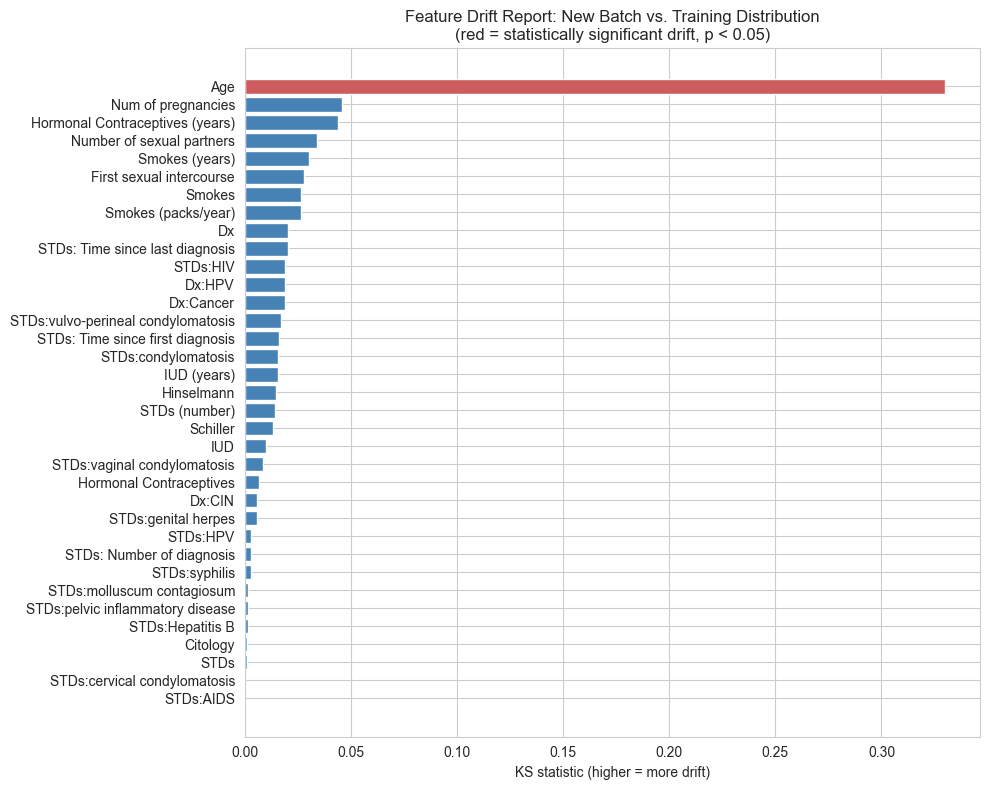

Drifted features: ['Age']


In [ ]:
# Visualize which features drifted the most.
plt.figure(figsize=(10, 8))
colors = drift_report["drifted"].map({True: "indianred", False: "steelblue"})
plt.barh(drift_report["feature"], drift_report["ks_statistic"], color=colors)
plt.xlabel("KS statistic (higher = more drift)")
plt.title("Feature Drift Report: New Batch vs. Training Distribution\n(red = statistically significant drift, p < 0.05)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Drifted features:", drift_report.loc[drift_report["drifted"], "feature"].tolist())


**Interpretation:** `Age` comes back with by far the highest KS statistic and `drifted = True`, exactly as expected since we deliberately shifted it. `Smokes (years)` was also perturbed but is *not* flagged as drifted - most patients report 0 years smoked, and multiplying 0 by 1.8 is still 0, so the shift is invisible to a statistical test on a mostly-zero column. This is itself a useful, realistic finding: a monitoring job can miss a real change in an input if that feature is dominated by a single value, which is exactly the kind of blind spot a real monitoring setup needs to be aware of.

In [ ]:
# 3. Monitor DEPLOYED MODEL PERFORMANCE on the drifted batch (labels available here only
# for demonstration; in production this metric would lag until outcomes are confirmed).
best_model_obj = next(r["model_obj"] for r in results if r["model_name"] == best_model_name)

baseline_f1 = results_df.loc[best_model_name, "f1_score"]
new_batch_preds = best_model_obj.predict(new_batch_scaled)
monitored_f1 = f1_score(new_batch_labels, new_batch_preds, zero_division=0)

f1_drop_pct = (baseline_f1 - monitored_f1) / baseline_f1 * 100

print(f"Baseline F1 (original test set): {baseline_f1:.3f}")
print(f"Monitored F1 (new/drifted batch): {monitored_f1:.3f}")
print(f"Relative F1 drop: {f1_drop_pct:.1f}%")


Baseline F1 (original test set): 0.750
Monitored F1 (new/drifted batch): 0.696
Relative F1 drop: 7.2%


In [ ]:
# 4. A simple automated monitoring rule: alert + recommend retraining if either
#    (a) more than 2 features show significant drift, or
#    (b) F1-score has dropped by more than 10% relative to the deployment baseline.
N_DRIFTED_THRESHOLD = 2
F1_DROP_THRESHOLD_PCT = 10

n_drifted = int(drift_report["drifted"].sum())
retrain_needed = (n_drifted > N_DRIFTED_THRESHOLD) or (f1_drop_pct > F1_DROP_THRESHOLD_PCT)

print(f"Drifted features: {n_drifted}/{len(drift_report)}")
print(f"F1 drop: {f1_drop_pct:.1f}%")
print("ALERT: retraining recommended!" if retrain_needed else "OK: model still healthy, no retraining needed.")


Drifted features: 1/35
F1 drop: 7.2%
OK: model still healthy, no retraining needed.


**Why this matters:** the assignment's marking scheme stops at Feast + Cloud Platform analysis, but a real MLOps pipeline is never actually done at deployment - the Monitoring stage from Task 1's own lifecycle diagram is what keeps a model trustworthy over time. This bonus section demonstrates that stage with runnable code: statistical drift detection (KS test), live performance tracking, and an automated retrain-or-not decision rule, all built only from data and the model already produced in Task 2 - no new infrastructure required.

## 6. Conclusion

### Key Findings
1. **Data quality:** the raw dataset has real missingness — 4 columns >90% missing (structural, tied to never having an STD diagnosis) and ~10 columns with 2–14% missingness (likely survey non-response). Median imputation was chosen for robustness to the skewed clinical distributions.
2. **Class imbalance:** the target `Biopsy` is ~94% negative / ~6% positive. Accuracy alone would be misleading (a trivial always-negative model scores ~94%), so **F1-score and Recall** were used as the deciding metrics — critical in a medical context where false negatives (missed cancer) are the costliest error.
3. **Model comparison:** three models (KNN, Random Forest, SVM) were trained on SMOTE-balanced training data and logged to MLflow; the best model was selected by F1-score (see Section 2.5 output for the exact winner and its Recall/Precision trade-off).
4. **Monitoring in practice (bonus):** a KS-test-based drift check plus live F1 tracking shows concretely how the Monitoring stage from Task 1 would catch a drifted patient population and trigger a retrain decision automatically.
5. **Reproducibility infrastructure:** DVC gives us auditable, rollback-able dataset versions (v1 raw vs. v2 processed); Kubeflow gives us a containerized, cacheable, horizontally-scalable pipeline; Feast provides centralized definitions for selected features and supports consistent retrieval of those features during training and inference; and MLflow ties every model back to the exact parameters and data version that produced it.


### Limitations & Future Work
- The dataset is small (858 rows); a production system would need continuous data collection to keep the model calibrated.
- SMOTE synthesizes data in feature space — clinically, a domain expert should validate that synthetic minority samples are physiologically plausible.
- DVC, Kubeflow, and Feast are run/simulated locally in this notebook; AWS SageMaker is the cloud platform selected for deployment (Task 5B). A production rollout would push the DVC remote to S3, run the Kubeflow pipeline on a managed Kubernetes cluster (e.g. EKS), and connect Feast to a production online store (e.g. DynamoDB) feeding a SageMaker endpoint.
